In [2]:
#| echo: false

# import image module
from IPython.display import Image

# get the image
Image(url="./images/data_preparation.webp",width=450, height=250)


After data cleaning removes quality issues (missing values, outliers, duplicates), **data preparation** transforms the cleaned data into a format optimized for modeling and analysis. While data cleaning ensures data quality, data preparation ensures data is in the **right structure, scale, and format** for algorithms to work effectively.

Data scientists often spend **20-30% of their time** on data preparation after cleaning, as most machine learning algorithms have specific requirements:

- **Numerical inputs only** (requiring encoding of categorical variables)
- **Similar feature scales** (preventing some features from dominating others)
- **Meaningful representations** (creating derived features that capture important patterns)



## Why Data Preparation Matters

| **Challenge** | **Issue** | **Solution** |
|---------------|-----------|--------------|
| **Information loss** | Continuous data may hide useful patterns | Bin values into meaningful groups |
| **Categorical data** | Algorithms require numbers, not text | Encode categories as dummy variables |
| **Scale differences** | Income ($50K) vs. Age (30) have different magnitudes | Normalize or standardize features |
| **Model performance** | Poorly prepared data leads to biased or inaccurate models | Apply appropriate transformations |

</br>

> **Note:** This chapter focuses on fundamental preparation techniques. Advanced feature engineering (creating interaction terms, polynomial features, domain-specific transformations) is typically covered in machine learning courses.


Let's first import necessary libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns

sns.set(font_scale=1.5)

%matplotlib inline

## Dataset Introduction

Throughout this chapter, we'll use the **College dataset** (`College.csv`) that contains information about US universities as our dataset in this section. The description of variables of the dataset can be found on page 65 of this [book](https://www.statlearning.com/resources-python).

We’ll demonstrate how binning and encoding can reveal meaningful patterns and support actionable recommendations for universities. Finally, we’ll apply feature scaling to prepare the data for predictive modeling.

Let's read the dataset into pandas dataframe

In [8]:
college = pd.read_csv('./datasets/College.csv', index_col=0)
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15


## Data Binning

Data binning is a practical technique in data analysis where continuous numerical values are grouped into discrete intervals, or "bins." Think of it as sorting a long list of numbers into a few meaningful categories—like putting marbles of different colors into separate jars. Binning helps us simplify complex data, spot patterns, and make comparisons that would be hard to see otherwise.

**Why do we use binning?**

- **Easier interpretation:** Instead of analyzing hundreds of unique values, we can summarize data into a handful of groups. For example, rather than looking at every possible age, we might use age groups like 'under 20', '20-30', '30-40', and '40 and over'.

- **Better recommendations:** Grouping data helps us make targeted decisions. For instance, a doctor might recommend different treatments for children, adults, and seniors—each defined by an age bin.

- **Noise reduction:** Binning can smooth out random fluctuations in data, making trends clearer. For example, daily sales numbers might be noisy, but weekly or monthly bins reveal the bigger picture.

**Real-world examples:**

- **Tax brackets:** Income is grouped into ranges (bins) to determine tax rates, such as 'up to $11,000', '$11,001 to $44,725', etc.
- **Credit card marketing:** Customers are binned as 'High spenders', 'Medium spenders', or 'Low spenders' to tailor marketing strategies.
- **Medical guidelines:** Vaccine recommendations often depend on age bins (e.g., under 12, 12-18, 18-65, over 65).

In this section, we'll see how binning can help us interpret and communicate insights from data, using real datasets and practical code examples. We'll also compare different binning methods and discuss when each is most useful.


In [9]:
#| echo: false

from IPython.display import Image, display, HTML

# Create HTML layout for side-by-side images
html_content = """
<div style="display: flex; gap: 50px;">
    <img src="./Datasets/taxable-income-2024.png" width="300" />
    <img src="./Datasets/bin_example1b.png" width="300", height="200" />
</div>
"""

# Display the images side by side
display(HTML(html_content))


Now, let's see how binning can help us uncover meaningful insights from our college dataset. We'll focus on two key variables: instructional expenditure per student (`Expend`) and graduation rate (`Grad.Rate`) for U.S. universities.


By grouping universities into expenditure bins, we can more clearly observe how spending levels relate to graduation outcomes. This approach not only simplifies the analysis but also enables us to make practical, data-driven recommendations for different types of institutions.


Before we apply binning, let's revisit the scatterplot of 'Grad.Rate' versus 'Expend' with a trendline. This plot shows the overall relationship, but as we'll see, binning can reveal patterns and actionable insights that might be hidden in the raw data.

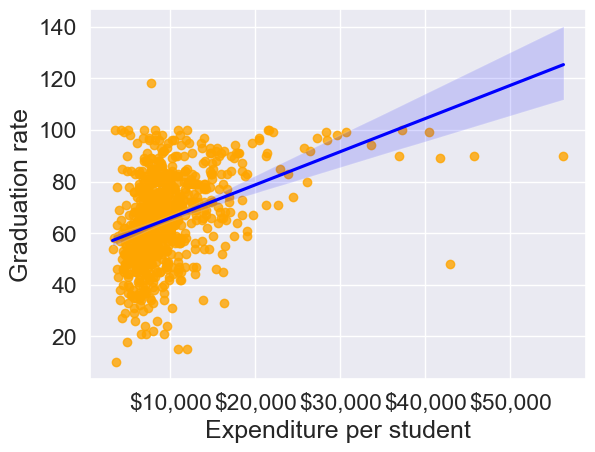

In [10]:
# scatter plot of Expend vs Grad.Rate
ax=sns.regplot(data = college, x = "Expend", y = "Grad.Rate",scatter_kws={"color": "orange"}, line_kws={"color": "blue"})
ax.xaxis.set_major_formatter('${x:,.0f}')
ax.set_xlabel('Expenditure per student')
ax.set_ylabel('Graduation rate')
plt.show()

The trendline indicates a positive correlation between `Expend` and `Grad.Rate`. However, there seems to be a lot of noise and presence of outliers in the data, which makes it hard to interpret the overall trend.

**Common Data Binning Methods**


There are several ways to create bins, each with its own advantages depending on your data and analysis goals:


- **Equal-width binning:** Divides the range of a variable into intervals of the same size. This is simple and works well when the data is uniformly distributed, but can result in bins with very different numbers of observations if the data is skewed or has outliers.
    - *Example:* Splitting ages 0–100 into five bins of 20 years each: 0–20, 21–40, 41–60, 61–80, 81–100.


- **Equal-size (quantile) binning:** Each bin contains (roughly) the same number of observations, regardless of the actual range of values. This is useful for comparing groups of similar size and for handling skewed data.
    - *Example:* Dividing 300 students into three bins so that each bin has 100 students, even if the score ranges are different.


- **Custom binning:** Bins are defined based on domain knowledge or specific cutoffs relevant to the problem. This approach is flexible and can make results more interpretable for your audience.
    - *Example:* Income groups defined as 'Low' (<$30,000), 'Middle' ($30,000–$70,000), and 'High' (>$70,000) based on policy or business needs.


In practice, the choice of binning method should be guided by the data distribution and the questions you want to answer. We'll demonstrate each of these methods in the following examples.

We'll bin `Expend` to see if we can better analyze its association with `Grad.Rate`. However, let us first visualize the distribution of `Expend`.

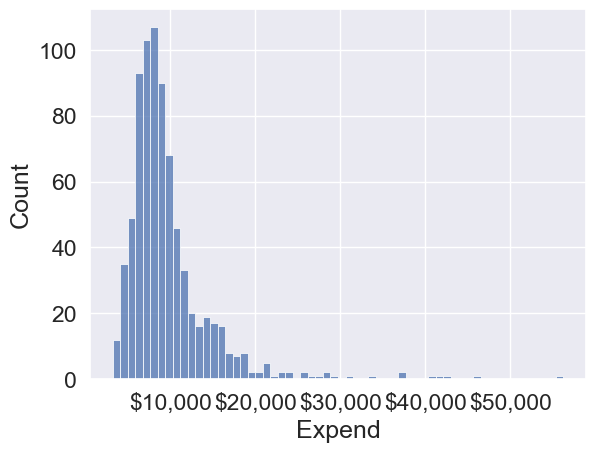

In [11]:
#Visualizing the distribution of expend
ax=sns.histplot(data = college, x= 'Expend')
ax.xaxis.set_major_formatter('${x:,.0f}')

The distribution of `Expend` is right skewed with potentially some extremely high outlying values.

### Equal-width Binning

Equal-width binning divides the range of `Expend` into intervals of the same size. This is useful for evenly spaced data, but can result in bins with very different numbers of universities if the data is skewed.

We'll use the Pandas function [`cut()`](https://pandas.pydata.org/docs/reference/api/pandas.cut.html) to create three equal-width bins for instructional expenditure.

In [12]:
#Using the cut() function in Pandas to bin "Expend"
Binned_expend = pd.cut(college['Expend'],3,retbins = True)
Binned_expend


(Abilene Christian University      (3132.953, 20868.333]
 Adelphi University                (3132.953, 20868.333]
 Adrian College                    (3132.953, 20868.333]
 Agnes Scott College               (3132.953, 20868.333]
 Alaska Pacific University         (3132.953, 20868.333]
                                           ...          
 Worcester State College           (3132.953, 20868.333]
 Xavier University                 (3132.953, 20868.333]
 Xavier University of Louisiana    (3132.953, 20868.333]
 Yale University                    (38550.667, 56233.0]
 York College of Pennsylvania      (3132.953, 20868.333]
 Name: Expend, Length: 777, dtype: category
 Categories (3, interval[float64, right]): [(3132.953, 20868.333] < (20868.333, 38550.667] < (38550.667, 56233.0]],
 array([ 3132.953     , 20868.33333333, 38550.66666667, 56233.        ]))

The [cut()](https://pandas.pydata.org/docs/reference/api/pandas.cut.html) function returns a tuple of length 2. The first element of the tuple are the bins, while the second element is an array containing the cut-off values for the bins.

In [13]:
type(Binned_expend)

tuple

In [14]:
len(Binned_expend)

2

Once the bins are obtained, we'll add a column in the dataset that indicates the bin for `Expend`.

In [15]:
#Creating a categorical variable to store the level of expenditure on a student
college['Expend_bin'] = Binned_expend[0]
college.head()

,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate,Expend_bin
Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60,"(3132.953, 20868.333]"
Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56,"(3132.953, 20868.333]"
Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54,"(3132.953, 20868.333]"
Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59,"(3132.953, 20868.333]"
Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15,"(3132.953, 20868.333]"


See the variable `Expend_bin` in the above dataset.

Let us visualize the `Expend` bins over the distribution of the `Expend` variable.

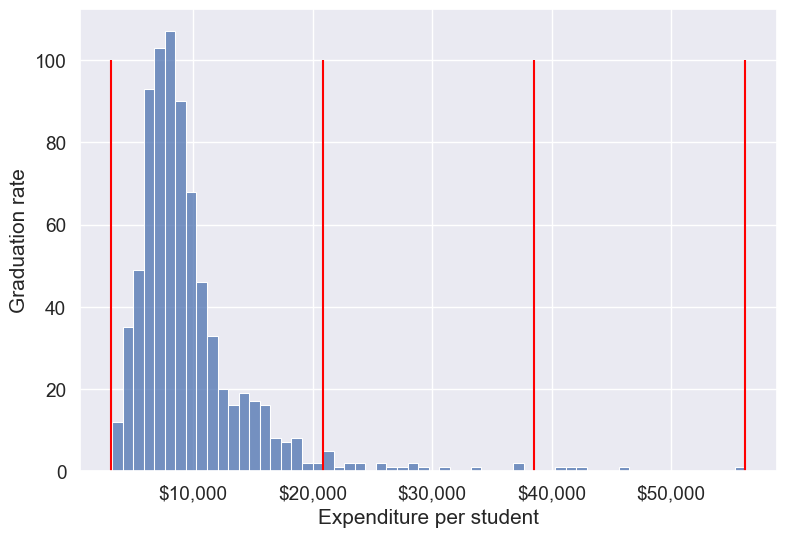

In [16]:
#Visualizing the bins for instructional expediture on a student
sns.set(font_scale=1.25)
plt.rcParams["figure.figsize"] = (9,6)
ax=sns.histplot(data = college, x= 'Expend')
plt.vlines(Binned_expend[1], 0,100,color='red')
plt.xlabel('Expenditure per student');
plt.ylabel('Graduation rate');
ax.xaxis.set_major_formatter('${x:,.0f}')

By default, the bins created have equal width. They are created by dividing the range between the maximum and minimum value of `Expend` into the desired number of equal-width intervals. We can label the bins as well as follows.

In [17]:
college['Expend_bin'] = pd.cut(college['Expend'],3,labels = ['Low expend','Med expend','High expend'])
college['Expend_bin']

Abilene Christian University       Low expend
Adelphi University                 Low expend
Adrian College                     Low expend
Agnes Scott College                Low expend
Alaska Pacific University          Low expend
                                     ...     
Worcester State College            Low expend
Xavier University                  Low expend
Xavier University of Louisiana     Low expend
Yale University                   High expend
York College of Pennsylvania       Low expend
Name: Expend_bin, Length: 777, dtype: category
Categories (3, object): ['Low expend' < 'Med expend' < 'High expend']

Now that we have binned the variable `Expend`, let us see if we can better visualize the association of graduation rate with expenditure per student using `Expened_bin`.

<Axes: xlabel='Expend_bin', ylabel='Grad.Rate'>

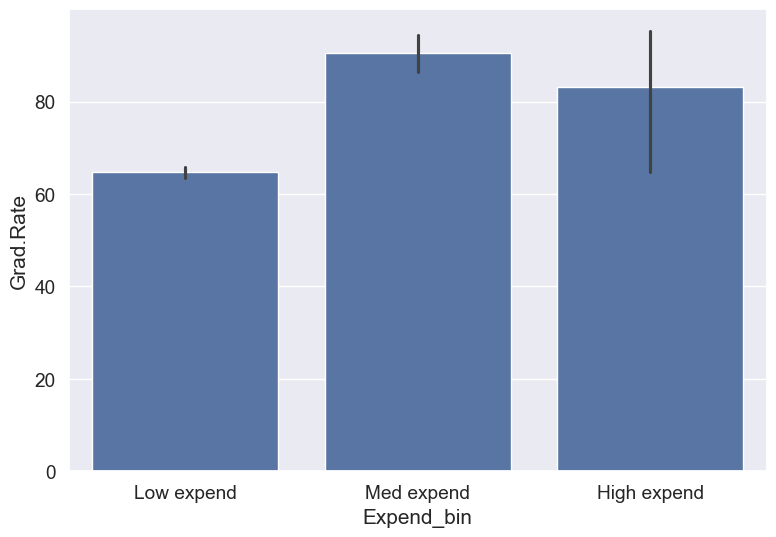

In [18]:
#Visualizing average graduation rate vs categories of instructional expenditure per student
sns.barplot(x = 'Expend_bin', y = 'Grad.Rate', data = college)

It seems that the graduation rate is the highest for universities with medium level of expenditure per student. This is different from the trend we saw earlier in the scatter plot. Let us investigate.

Let us find the number of universities in each bin.

In [21]:
college['Expend_bin'].value_counts()

Expend_bin
Low expend     751
Med expend      21
High expend      5
Name: count, dtype: int64

The bin `High expend` consists of only 5 universities, or 0.6% of all the universities in the dataset. These universities may be outliers that are skewing the trend (as also evident in the histogram above). 

Let us see if we get the correct trend with the outliers removed from the data.

#### Removing outliers in `Expend` (setup for fair comparisons)

Before we compare graduation rates across expenditure levels, we’ll remove extreme outliers in instructional expenditure (`Expend`) so they don’t distort averages. We’ll use the IQR rule (Q1 − 1.5×IQR, Q3 + 1.5×IQR) to define lower and upper bounds and filter the dataset. This also defines `lower_bound` and `upper_bound` used later.

In [25]:
#Data without outliers

Q1 = college['Expend'].quantile(0.25)
Q3 = college['Expend'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

college_data_without_outliers = college[((college.Expend>=lower_bound) & (college.Expend<=upper_bound))]

Let's visualize 'Expend' before and after outlier removal and show bounds

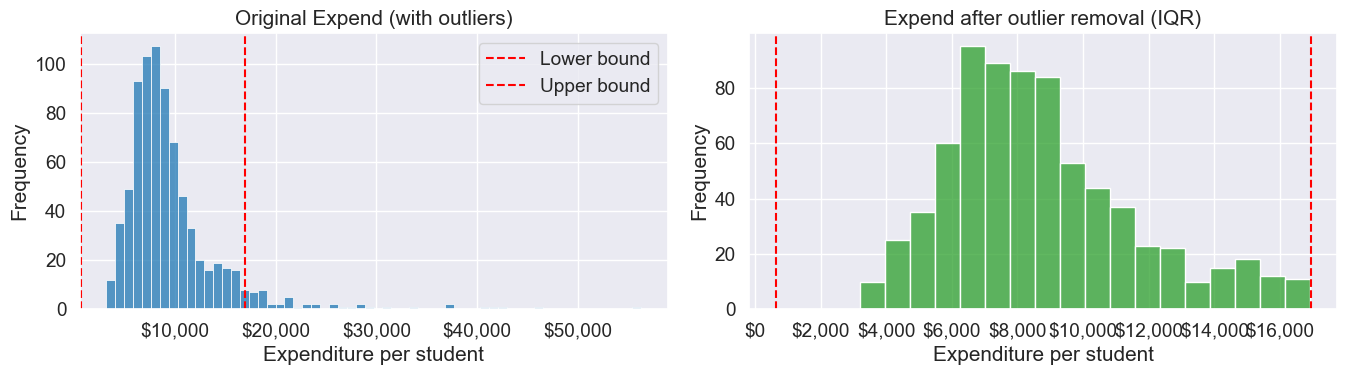

Q1 = 6,751, Q3 = 10,830
IQR = 4,079
Lower bound = 632, Upper bound = 16,948


In [26]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(college['Expend'], ax=axes[0], color='tab:blue')
axes[0].axvline(lower_bound, color='red', linestyle='--', label='Lower bound')
axes[0].axvline(upper_bound, color='red', linestyle='--', label='Upper bound')
axes[0].set_title('Original Expend (with outliers)')
axes[0].set_xlabel('Expenditure per student')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter('${x:,.0f}')
axes[0].legend()

sns.histplot(college_data_without_outliers['Expend'], ax=axes[1], color='tab:green')
axes[1].axvline(lower_bound, color='red', linestyle='--')
axes[1].axvline(upper_bound, color='red', linestyle='--')
axes[1].set_title('Expend after outlier removal (IQR)')
axes[1].set_xlabel('Expenditure per student')
axes[1].set_ylabel('Frequency')
axes[1].xaxis.set_major_formatter('${x:,.0f}')

plt.tight_layout()
plt.show()

print(f"Q1 = {Q1:,.0f}, Q3 = {Q3:,.0f}")
print(f"IQR = {IQR:,.0f}")
print(f"Lower bound = {lower_bound:,.0f}, Upper bound = {upper_bound:,.0f}")

Note that the right tail of the histogram has disappered since we removed outliers.

Let’s recreate the bins with equal size and visualize the relationship.

In [27]:
Binned_data = pd.cut(college_data_without_outliers['Expend'],3,labels = ['Low expend','Med expend','High expend'],retbins = True)
college_data_without_outliers.loc[:,'Expend_bin'] = Binned_data[0]

<Axes: xlabel='Expend_bin', ylabel='Grad.Rate'>

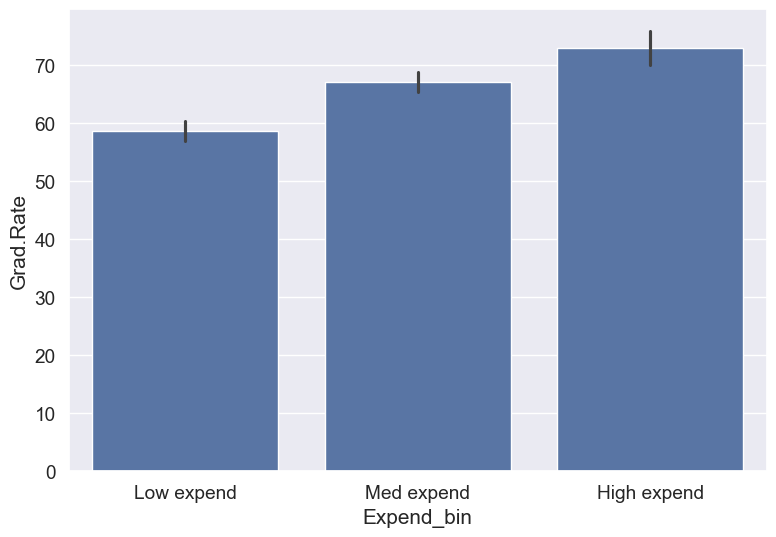

In [28]:
sns.barplot(x = 'Expend_bin', y = 'Grad.Rate', data = college_data_without_outliers)

With the outliers removed, we obtain the correct overall trend, even in the case of equal-width bins. Note that these bins have unequal number of observations as shown below.

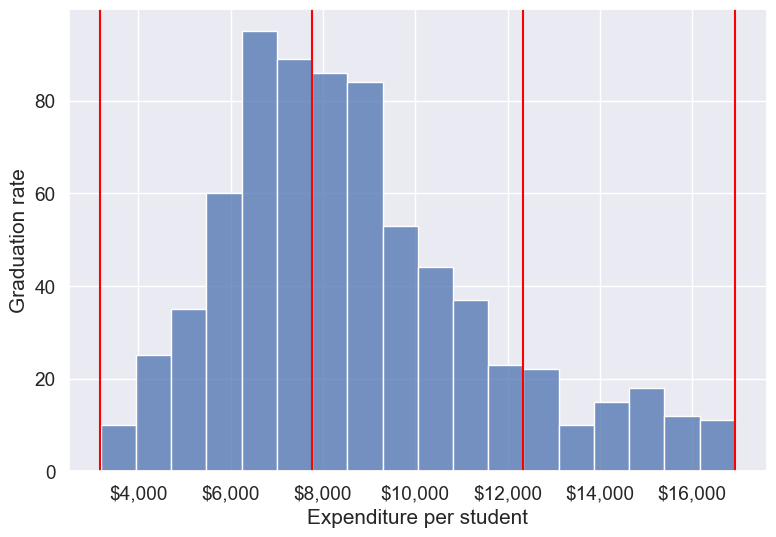

In [29]:
ax=sns.histplot(data = college_data_without_outliers, x= 'Expend')
for i in range(4):
    plt.axvline(Binned_data[1][i], 0,100,color='red')
plt.xlabel('Expenditure per student');
plt.ylabel('Graduation rate');
ax.xaxis.set_major_formatter('${x:,.0f}')

In [30]:
college_data_without_outliers['Expend_bin'].value_counts()

Expend_bin
Med expend     327
Low expend     314
High expend     88
Name: count, dtype: int64

Instead of removing outliers, we can address the issue by binning observations into equal-sized bins, ensuring each bin has the same number of observations. Let’s explore this approach next.

### Equal-size (quantile) Binning

Equal-sized (quantile) binning splits a variable so that each bin contains approximately the same number of observations. This is especially helpful for skewed distributions and makes comparisons across groups fair. We'll use `pd.qcut()` to divide `Expend` into three equally sized groups (tertiles).

Let us bin the variable `Expend` such that each bin consists of the same number of observations.

In [82]:
#Using the Pandas function qcut() to create bins with the same number of observations
Binned_expend = pd.qcut(college['Expend'],3,retbins = True)
college['Expend_bin'] = Binned_expend[0]

Let's check the number of obervations in each bin

In [83]:
college['Expend_bin'].value_counts()

Expend_bin
(3185.999, 7334.333]    259
(7334.333, 9682.333]    259
(9682.333, 56233.0]     259
Name: count, dtype: int64

Let us visualize the `Expend` bins over the distribution of the `Expend` variable.

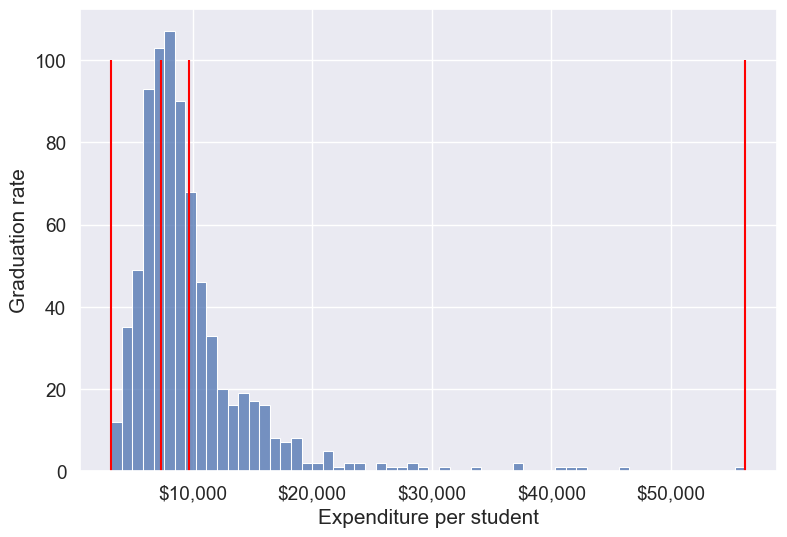

In [84]:
#Visualizing the bins for instructional expediture on a student
sns.set(font_scale=1.25)
plt.rcParams["figure.figsize"] = (9,6)
ax=sns.histplot(data = college, x= 'Expend')
plt.vlines(Binned_expend[1], 0,100,color='red')
plt.xlabel('Expenditure per student');
plt.ylabel('Graduation rate');
ax.xaxis.set_major_formatter('${x:,.0f}')

Note that the bin-widths have been adjusted to have the same number of observations in each bin. The bins are narrower in domains of high density, and wider in domains of sparse density.

Let us again make the barplot visualizing the average graduate rate with level of instructional expenditure per student.

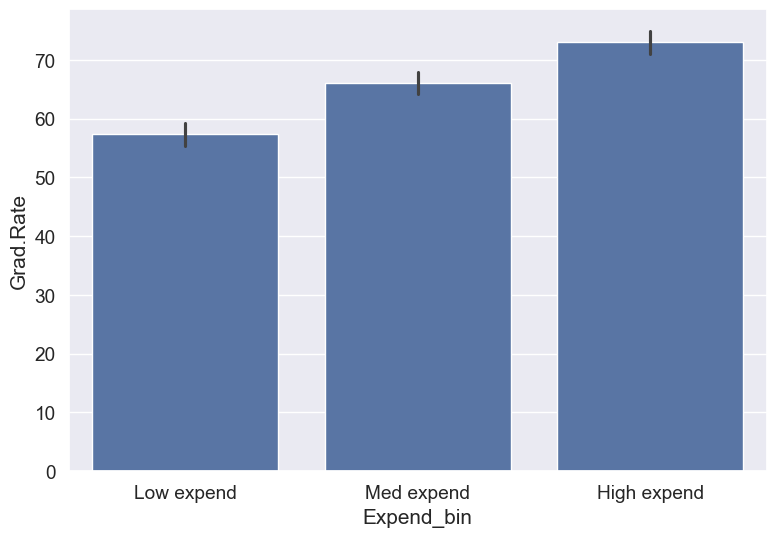

In [85]:
college['Expend_bin'] = pd.qcut(college['Expend'],3,labels = ['Low expend','Med expend','High expend'])
a=sns.barplot(x = 'Expend_bin', y = 'Grad.Rate', data = college)

Now we see the same trend that we saw in the scatterplot, but without the noise. We have smoothed the data. Note that making equal-sized bins helps reduce the effect of outliers in the overall trend.

Suppose this analysis was done to provide recommendations to universities for increasing their graduation rate. With binning, we can can provide one recommendation to *'Low expend'* universities, and another one to *'Med expend'* universities. For example, the recommendations can be: 

1. *'Low expend'* universities can expect an increase of 9 percentage points in `Grad.Rate`, if they migrate to the *'Med expend'* category.
2. *'Med expend'* universities can expect an increase of 7 percentage points in `Grad.Rate`, if they migrate to the *'High expend'* category.

The numbers in the above recommendations are based on the table below.

In [86]:
college.groupby(college.Expend_bin, observed=False)['Grad.Rate'].mean()

Expend_bin
Low expend     57.343629
Med expend     66.057915
High expend    72.988417
Name: Grad.Rate, dtype: float64

We can also provide recommendations based on the confidence intervals of the mean graduation rate (`Grad.Rate`). The confidence intervals, calculated below, are derived using a method known as bootstrapping. For a detailed explanation of bootstrapping, please refer to [this article on Wikipedia](https://en.wikipedia.org/wiki/Bootstrapping_(statistics)).

In [87]:
# Bootstrapping to find 95% confidence intervals of Graduation Rate of US universities based on average expenditure per student
confidence_intervals = {}

# Loop through each expenditure bin
for expend_bin, data_sub in college.groupby('Expend_bin', observed=False):
    # Generate bootstrap samples for the graduation rate
    samples = np.random.choice(data_sub['Grad.Rate'], size=(10000, len(data_sub)), replace=True)
    
    # Calculate the mean of each sample
    sample_means = samples.mean(axis=1)
    
    # Calculate the 95% confidence interval
    lower_bound = np.percentile(sample_means, 2.5)
    upper_bound = np.percentile(sample_means, 97.5)
    
    # Store the result in the dictionary
    confidence_intervals[expend_bin] = (round(lower_bound, 2), round(upper_bound, 2))

# Print the results
for expend_bin, ci in confidence_intervals.items():
    print(f"95% Confidence interval of Grad.Rate for {expend_bin} universities = [{ci[0]}, {ci[1]}]")


95% Confidence interval of Grad.Rate for Low expend universities = [55.36, 59.36]
95% Confidence interval of Grad.Rate for Med expend universities = [64.15, 67.95]
95% Confidence interval of Grad.Rate for High expend universities = [71.03, 74.92]


Apart from equal-width and equal-sized bins, custom bins can be created using the *bins* argument. Suppose, bins are to be created for `Expend` with cutoffs $\$10,000, \$20,000, \$30,000... \$60,000$. Then, we can use the *bins* argument as in the code below:

### Custom Binning

Sometimes your analysis calls for bins that match business rules or domain thresholds rather than equal-width or equal-size splits. With `pd.cut()`, you can supply exact edges and readable labels to get bins that make sense for your audience.

Practical tips:

- Choose edges based on policy or domain knowledge (e.g., <$10K, $10K–$40K, >$40K).
- Use `include_lowest=True` to ensure the minimum value is captured by the first bin, and `right` to control which side of the interval is closed (default is right-closed).
- To avoid leaving values outside your bins, use open-ended edges with `-np.inf` and `np.inf`.
- Provide human-friendly `labels`; the result is an ordered categorical, so plots and tables keep the intended order.

We’ll demonstrate two patterns:

1) Fixed-width $10K bins (for a quick grid-like view)
2) Domain-based bins (Low/Medium/High) with open-ended edges

In [31]:
# Example 1: fixed-width $10K bins up to $60K
edges_10k = list(range(0, 70000, 10000))
Expend_bins_10k = pd.cut(
    college['Expend'],
    bins=edges_10k,
    include_lowest=True,
    right=False,   # intervals are [left, right)
    ordered=True,
    retbins=True
)

# Save the categorical bins as a new column
college['Expend_bin_custom_10k'] = Expend_bins_10k[0]

# Show counts and proportions per bin
counts_10k = college['Expend_bin_custom_10k'].value_counts().sort_index()
summary_10k = pd.DataFrame({
    'count': counts_10k,
    'proportion': (counts_10k / len(college)).round(3)
})
summary_10k

,count,proportion
Expend_bin_custom_10k,,
"[0, 10000)",535,0.689
"[10000, 20000)",214,0.275
"[20000, 30000)",19,0.024
"[30000, 40000)",4,0.005
"[40000, 50000)",4,0.005
"[50000, 60000)",1,0.001


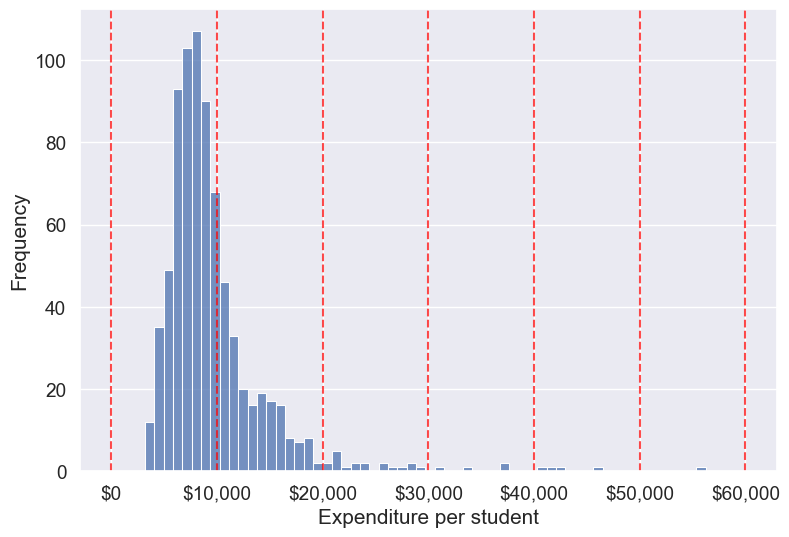

In [32]:
# Visualizing the fixed $10K bins over the Expend distribution
sns.set(font_scale=1.25)
plt.rcParams["figure.figsize"] = (9,6)
ax = sns.histplot(data=college, x='Expend')
for edge in edges_10k:
    ax.axvline(edge, color='red', linestyle='--', alpha=0.7)
plt.xlabel('Expenditure per student')
plt.ylabel('Frequency')
ax.xaxis.set_major_formatter('${x:,.0f}')
plt.show()

Next, let's create a domain-based set of custom bins with unequal widths using open-ended edges. This pattern ensures every value is assigned to a bin (no NaNs from falling outside the range) and keeps the labels interpretable for stakeholders.

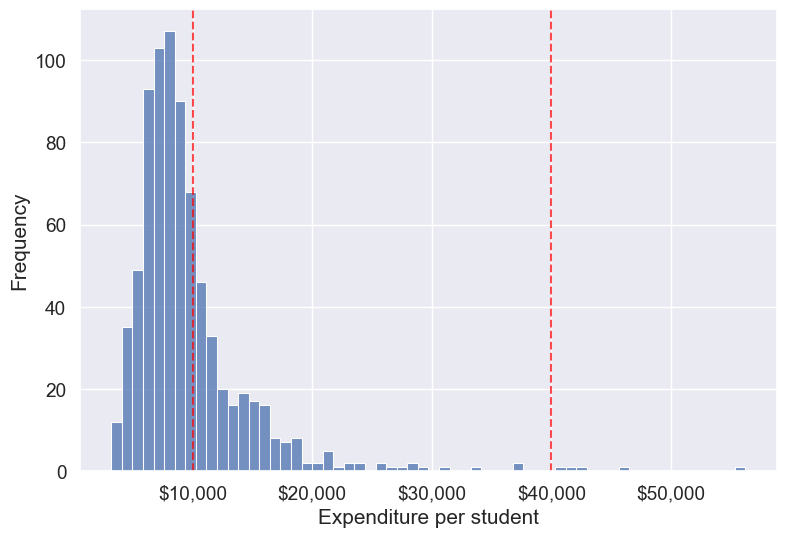

In [33]:
# Example 2: domain-based custom bins with open-ended edges
bins = [-np.inf, 10000, 40000, np.inf]
labels = ['Low Expenditure', 'Medium Expenditure', 'High Expenditure']

# Binning the 'Expend' column (ordered categorical)
college['Expend_bin_custom'] = pd.cut(
    college['Expend'], bins=bins, labels=labels, ordered=True, include_lowest=True
)

# Visualizing the bins using a histogram
ax = sns.histplot(data=college, x='Expend', kde=False)
# Add vertical lines for the finite bin edges
for edge in bins:
    if np.isfinite(edge):
        ax.axvline(edge, color='red', linestyle='--', alpha=0.7)

# Labels and formatting
plt.xlabel('Expenditure per student')
plt.ylabel('Frequency')
ax.xaxis.set_major_formatter('${x:,.0f}')
plt.show()

In [34]:
# Check counts and proportions per custom (domain-based) bin
counts_custom = college['Expend_bin_custom'].value_counts().sort_index()
summary_custom = pd.DataFrame({
    'count': counts_custom,
    'proportion': (counts_custom / len(college)).round(3)
})
summary_custom

,count,proportion
Expend_bin_custom,,
Low Expenditure,535,0.689
Medium Expenditure,237,0.305
High Expenditure,5,0.006


Compute mean graduation rate by these custom bins without using groupby (we’ll use a pivot table, which preserves the categorical bin order).

In [39]:
college.groupby(college.Expend_bin_custom, observed=False)['Grad.Rate'].mean().round(2)

Expend_bin_custom
Low Expenditure       61.79
Medium Expenditure    73.37
High Expenditure      83.20
Name: Grad.Rate, dtype: float64

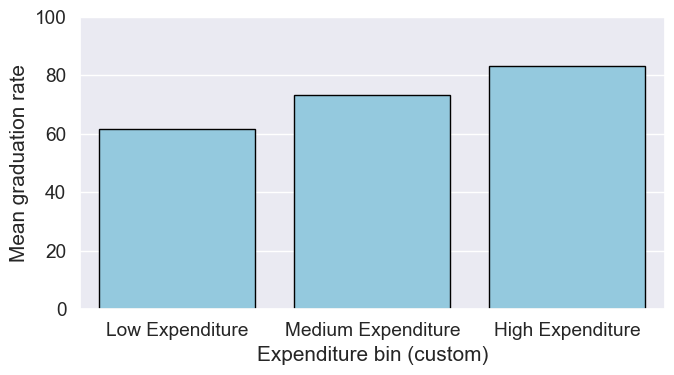

In [40]:
# Draw bar plot using the groupby result
means_by_custom = college.groupby(college.Expend_bin_custom, observed=False)['Grad.Rate'].mean().round(2)
plt.figure(figsize=(7,4))
sns.barplot(x=means_by_custom.index.astype(str), y=means_by_custom.values, color='skyblue', edgecolor='black')
plt.xlabel('Expenditure bin (custom)')
plt.ylabel('Mean graduation rate')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

As custom bin-cutoffs can be specified with the `cut()` function, custom bin quantiles can be specified with the `qcut()` function.

## Encoding Categorical Variables

Many machine learning algorithms require numerical input, so categorical variables (text labels or categories) must be converted to numbers. There are two main approaches: label encoding and one-hot encoding. The choice depends on the nature of the variable and the model you plan to use.

### Label Encoding

Label encoding assigns each unique category in a variable a unique integer value. This is simple and memory-efficient, but it can introduce unintended ordinal relationships (e.g., 0 < 1 < 2) that may mislead some models.

**When to use:**

- For ordinal variables (where categories have a natural order, e.g., 'Low', 'Medium', 'High').
- For target variables in classification tasks, where labels must be numeric. 

**When to avoid:**
- For nominal variables (no order), especially with linear models, as the numeric codes may be misinterpreted as ordered.

Let's use the 'Private' column (Yes/No) in the college dataset as an example

In [ ]:
# Example: Label encoding a categorical column
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
college['Private_label'] = le.fit_transform(college['Private'])
college[['Private', 'Private_label']].head()

,Private,Private_label
Abilene Christian University,Yes,1
Adelphi University,Yes,1
Adrian College,Yes,1
Agnes Scott College,Yes,1
Alaska Pacific University,Yes,1


### One-Hot Encoding

One-hot encoding creates a new binary column for each category, with a 1 indicating the presence of that category and 0 otherwise. This avoids introducing any ordinal relationship between categories.

**When to use:**
- For nominal variables (no natural order), e.g., 'State', 'Major', 'Color'.
- For most linear models and neural networks.

**When to avoid:**
- When the variable has many unique categories (can create too many columns, known as the "curse of dimensionality").

#### How to Create Dummy variables

The pandas library in Python has a built-in function, [`pd.get_dummies()`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html), to generate dummy variables.
If a column in a DataFrame has $k$ distinct values, we will get a DataFrame with $k$ columns containing 0s and 1s

Let us make dummy variables with the equal-sized bins we created for the average instruction expenditure per student.

In [81]:
#Using the Pandas function qcut() to create bins with the same number of observations
Binned_expend = pd.qcut(college['Expend'],3,retbins = True,labels = ['Low_expend','Med_expend','High_expend'])
college['Expend_bin'] = Binned_expend[0]

In [83]:
#Making dummy variables based on the levels (categories) of the 'Expend_bin' variable
dummy_Expend = pd.get_dummies(college['Expend_bin'], dtype=int)

The dummy data `dummy_Expend` has a value of $1$ if the observation corresponds to the category referenced by the column name.

In [84]:
dummy_Expend.head()

,Low_expend,Med_expend,High_expend
0,1,0,0
1,0,0,1
2,0,1,0
3,0,0,1
4,0,0,1


Adding the dummy columns back to the original dataframe

In [85]:
#Concatenating the dummy variables to the original data
college = pd.concat([college,dummy_Expend],axis=1)
print(college.shape)
college.head()

(777, 26)


,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,perc.alumni,Expend,Grad.Rate,z_score,is_z_score_outlier,is_IQR_outlier,Expend_bin,Low_expend,Med_expend,High_expend
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,12,7041,60,-0.501910,False,False,Low_expend,1,0,0
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,16,10527,56,0.166110,False,False,High_expend,0,0,1
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,30,8735,54,-0.177290,False,False,Med_expend,0,1,0
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,37,19016,59,1.792851,False,True,High_expend,0,0,1
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,2,10922,15,0.241803,False,False,High_expend,0,0,1


We can find the correlation between the dummy variables and graduation rate to identify if any of the dummy variables will be useful to estimate graduation rate (`Grad.Rate`).

In [229]:
#Finding if dummy variables will be useful to estimate 'Grad.Rate'
dummy_Expend.corrwith(college['Grad.Rate'])

Low_expend    -0.334456
Med_expend     0.024492
High_expend    0.309964
dtype: float64

The dummy variables `Low expend` and `High expend` may contribute in explaining `Grad.Rate` in a regression model.

#### Using `drop_first` to Avoid Multicollinearity

In cases like linear regression, you may want to drop one dummy variable to avoid multicollinearity (perfect correlation between variables).

In [86]:
# create dummy variables, dropping the first to avoid multicollinearity
dummy_Expend = pd.get_dummies(college['Expend_bin'], dtype=int, drop_first=True)

# add the dummy variables to the original dataset
college = pd.concat([college, dummy_Expend], axis=1)

college.head()

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,...,Grad.Rate,z_score,is_z_score_outlier,is_IQR_outlier,Expend_bin,Low_expend,Med_expend,High_expend,Med_expend,High_expend
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,...,60,-0.501910,False,False,Low_expend,1,0,0,0,0
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,...,56,0.166110,False,False,High_expend,0,0,1,0,1
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,...,54,-0.177290,False,False,Med_expend,0,1,0,1,0
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,...,59,1.792851,False,True,High_expend,0,0,1,0,1
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,...,15,0.241803,False,False,High_expend,0,0,1,0,1


## Feature Scaling

Feature scaling is a crucial step in data preparation, especially for machine learning algorithms that are sensitive to the scale of input features. Scaling ensures that numerical features contribute equally to model training and prevents features with larger ranges from dominating those with smaller ranges.

**Why scale features?**

- Many algorithms (e.g., k-nearest neighbors, k-means, principal component analysis, gradient descent-based models) compute distances or rely on feature magnitude.
- Features with larger scales can unduly influence the model if not scaled.

**Common scaling methods:**

- **Min-Max Scaling:** Rescales features to a fixed range, usually [0, 1].
- **Standardization (Z-score):** Centers features by removing the mean and scaling to unit variance.

> **Note:** Only continuous numerical features should be scaled. **Do not scale encoded categorical variables (such as label-encoded or one-hot encoded columns)**. Scaling these can distort their meaning and introduce unintended relationships. For example, one-hot encoded columns are already binary (0/1), and scaling them would break their interpretation as category indicators.



### How to Scale Features in Practice

Let's demonstrate how to scale the continuous numerical features in the college dataset. We'll use both Min-Max scaling and Standardization (Z-score). We'll **exclude all categorical and encoded categorical variables** from scaling, including:

- The original 'Private' column (categorical)
- Any label-encoded columns (e.g., 'Private_label')
- Any one-hot/dummy variables (e.g., columns created by `pd.get_dummies`)

Scaling these columns would destroy their categorical meaning. For example, one-hot encoded columns are meant to be 0 or 1, representing category membership. Scaling would turn them into non-binary values, which is not meaningful for models.

In [44]:
# Select only continuous numerical columns for scaling
# Exclude categorical, label-encoded, and dummy variables
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Identify columns to exclude (categorical and encoded)
categorical_cols = ['Private', 'Private_label']
dummy_cols = [col for col in college.columns if col in ['Low_expend', 'Med_expend', 'High_expend'] or set(col.split('_')).intersection({'Low', 'Med', 'High'})]

# Get all numeric columns
numeric_cols = college.select_dtypes(include=[float, int]).columns.tolist()

# Remove encoded categorical columns from scaling
cols_to_scale = [col for col in numeric_cols if col not in categorical_cols + dummy_cols]

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
college_minmax_scaled = college.copy()
college_minmax_scaled[cols_to_scale] = minmax_scaler.fit_transform(college[cols_to_scale])

# Standardization (Z-score)
standard_scaler = StandardScaler()
college_standard_scaled = college.copy()
college_standard_scaled[cols_to_scale] = standard_scaler.fit_transform(college[cols_to_scale])

# Show the first few rows of the scaled data
college_minmax_scaled[cols_to_scale].head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,0.032887,0.044177,0.107913,0.231579,0.472527,0.087164,0.024548,0.263430,0.239596,0.157754,0.297710,0.652632,0.710526,0.418231,0.187500,0.072671,0.462963
Adelphi University,0.043842,0.070531,0.075035,0.157895,0.219780,0.080752,0.056148,0.513430,0.736129,0.291444,0.190840,0.221053,0.078947,0.260054,0.250000,0.138387,0.425926
Adrian College,0.028055,0.039036,0.047349,0.221053,0.450549,0.028473,0.004488,0.460227,0.310530,0.135472,0.139695,0.473684,0.552632,0.278820,0.468750,0.104605,0.407407
Agnes Scott College,0.006998,0.010549,0.016045,0.621053,0.879121,0.011776,0.002839,0.548554,0.578499,0.157754,0.095420,0.884211,0.960526,0.139410,0.578125,0.298415,0.453704
Alaska Pacific University,0.002333,0.002818,0.003146,0.157895,0.384615,0.003492,0.039753,0.269628,0.368852,0.313725,0.190840,0.715789,0.631579,0.252011,0.031250,0.145833,0.046296


In [45]:
# Show the first few rows of the standardized (Z-score) scaled data
college_standard_scaled[cols_to_scale].head()

,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
Abilene Christian University,-0.346882,-0.321205,-0.063509,-0.258583,-0.191827,-0.168116,-0.209207,-0.746356,-0.964905,-0.602312,1.270045,-0.163028,-0.115729,1.013776,-0.867574,-0.501910,-0.318252
Adelphi University,-0.210884,-0.038703,-0.288584,-0.655656,-1.353911,-0.209788,0.244307,0.457496,1.909208,1.215880,0.235515,-2.675646,-3.378176,-0.477704,-0.544572,0.166110,-0.551262
Adrian College,-0.406866,-0.376318,-0.478121,-0.315307,-0.292878,-0.549565,-0.497090,0.201305,-0.554317,-0.905344,-0.259582,-1.204845,-0.931341,-0.300749,0.585935,-0.177290,-0.667767
Agnes Scott College,-0.668261,-0.681682,-0.692427,1.840231,1.677612,-0.658079,-0.520752,0.626633,0.996791,-0.602312,-0.688173,1.185206,1.175657,-1.615274,1.151188,1.792851,-0.376504
Alaska Pacific University,-0.726176,-0.764555,-0.780735,-0.655656,-0.596031,-0.711924,0.009005,-0.716508,-0.216723,1.518912,0.235515,0.204672,-0.523535,-0.553542,-1.675079,0.241803,-2.939613


**Summary: When and What to Scale**

- **Always scale continuous numerical features** before using algorithms sensitive to feature magnitude (e.g., k-means, k-NN, PCA, neural networks).
- **Never scale categorical variables or their encoded versions** (label-encoded or one-hot/dummy variables). Scaling these destroys their categorical meaning and can confuse models.
- For tree-based models (e.g., decision trees, random forests), scaling is not required, as these models are insensitive to feature scale.

## Independent Study

### Practice exercise 1

Read *survey_data_clean.csv*. Split the columns of the dataset, such that all columns with categorical values transform into dummy variables with each category corresponding to a column of 0s and 1s. Leave the *Timestamp* column. 

As all categorical columns are transformed to dummy variables, all columns have numeric values. 

What is the total number of columns in the transformed data? What is the total number of columns of the original data?

Find the:

1. Top 5 variables having the highest positive correlation with `NU_GPA`.

2. Top 5 variables having the highest negative correlation with `NU_GPA`.

### Practice exercise 2

Consider the dataset *survey_data_clean.csv* . Find the number of outliers in each column of the dataset based on both the Z-score and IQR criteria. Do not use a `for` loop.

Which column(s) have the maximum number of outliers using Z-score?

Which column(s) have the maximum number of outliers using IQR?

Do you think the outlying observations identified for those columns(s) should be considered as outliers? If not, then which type of columns should be considered when finding outliers?